# ML_CaseStudy_DataPrep_and_Baseline

Magnus H

Case study from data ingestion to baseline benchmarking. The workflow includes dataset auditing, preprocessing for model readiness, and a first benchmark using a 1-Nearest Neighbor classifier with L2 Euclidean distance. Results provide a reproducible baseline, serving as a starting point for more advanced modeling and feature engineering.

Summery: Using a small structured dataset (Iris-type flower data), SVM models delivered near-perfect accuracy — proving how solid preprocessing and simple models can already yield strong, reliable baselines

## Import dataset into Jupyter environment

Manually uploaded files

In [ ]:
import zipfile

zip_path = 'Images.zip'
extract_path = 'Images'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Load images to an array and create


Create (n,x,y,3) array turning dataset into a tensor of images
n → number of samples (images in the dataset).

x, y → spatial dimensions of each image (height and width).

3 → the three color channels (RGB).


In [ ]:
import numpy as np
from PIL import Image
import os

DATA_PATH = 'Images'
DATA_CATEGORIES = ["cat", "chicken", "dog", "horse"]

x_dataset = []
l_dataset = []


for category in DATA_CATEGORIES:
    category_path = os.path.join(DATA_PATH, category)
    for file_name in os.listdir(category_path):
        file_path = os.path.join(category_path, file_name)
        if file_name.endswith('.jpeg'):  # Only load .jpg files
            image = Image.open(file_path)
            image_resized = image.resize((50, 50))
            x_dataset.append(np.array(image_resized))
            l_dataset.append(category)  # Labels

# (n,x,y,3) array
x_dataset = np.array(x_dataset, dtype=np.float32)
l_dataset = np.array(l_dataset)

print("Image data shape:", x_dataset.shape)
print("Labels shape:", l_dataset.shape)

Image data shape: (40, 50, 50, 3)
Labels shape: (40,)



### Plotting a sample PlotSample

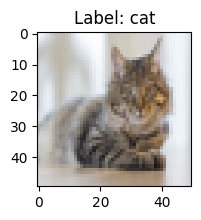

In [ ]:
import matplotlib.pyplot as plt


def plotSample(index):
    # Getting image
    sample = x_dataset[index]
    label = l_dataset[index]

    # Plot
    plt.figure(figsize=(2, 2))
    plt.imshow(sample.astype(np.uint8))
    plt.title(f"Label: {label}")
    plt.show()

plotSample(0)

### Preprocessing for deep learning - Based on Web tutorial

In [ ]:
# Normalize data
x_dataset_normalized = x_dataset / 255.0
print("Shape:", x_dataset_normalized.shape)
print("Max value:", np.max(x_dataset_normalized))
print("Min value:", np.min(x_dataset_normalized))

Shape: (40, 50, 50, 3)
Max value: 1.0
Min value: 0.0


In [ ]:
# Mean Normalization - Calculate the mean image and center the data
mean_image = np.mean(x_dataset_normalized, axis=0)
x_dataset_centered = x_dataset_normalized - mean_image
print("Mean image shape:", mean_image.shape)
print("Max value:", np.max(x_dataset_centered))
print("Min value:", np.min(x_dataset_centered))


Mean image shape: (50, 50, 3)
Max value: 0.7035295
Min value: -0.63529414


In [ ]:
# Have to flatten data for convn
x_dataset_flat = x_dataset_centered.reshape(x_dataset_centered.shape[0], -1)
print("Shape:", x_dataset_flat.shape)

Shape: (40, 7500)


In [ ]:
# Covariance Matrix
cov_matrix = np.cov(x_dataset_flat, rowvar=False)
print("Shape:", cov_matrix.shape)
print("Max value:", np.max(cov_matrix))
print("Min value:", np.min(cov_matrix))

Shape: (7500, 7500)
Max value: 0.1378790834031707
Min value: -0.04905013988214695


In [ ]:
# SVD on the Covariance Matrix
U, S, V = np.linalg.svd(cov_matrix) # singular value
epsilon = 0.1
print("U shape:", U.shape)
print("S shape:", S.shape)
print("V shape:", V.shape)

U shape: (7500, 7500)
S shape: (7500,)
V shape: (7500, 7500)


In [ ]:
# ZCA Whitening Matrix
ZCA_matrix = U.dot(np.diag(1.0 / np.sqrt(S + epsilon))).dot(U.T)
x_dataset_ZCA = x_dataset_flat.dot(ZCA_matrix.T)

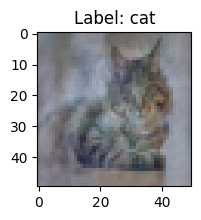

In [ ]:
# Rescale the whitened data
x_dataset_ZCA_rescaled = (x_dataset_ZCA - np.min(x_dataset_ZCA)) / (np.max(x_dataset_ZCA) - np.min(x_dataset_ZCA))

# Rescale to 0, 255 for visualization
x_dataset_ZCA_rescaled = (x_dataset_ZCA_rescaled * 255).astype(np.uint8)

# Reshape x_dataset_ZCA_rescaled to original
x_dataset = x_dataset_ZCA_rescaled.reshape(x_dataset_centered.shape)

# Show what happened after preprocessing using plotSample
plotSample(0)



### Import dataset into Jupyter environment



In [ ]:
import numpy as np

# Load npy
data = np.load('vecs.npy', allow_pickle=True).item()

### Explore what we got to work with.

In [ ]:
import numpy as np

# Load the data
data = np.load('vecs.npy', allow_pickle=True).item()

# Getting basic information about the data structure
print("Data type:", type(data))  # Shows that 'data' is a dictionary
print("Keys:", list(data.keys()))

# and examine the contents of a sample position
sample_position = list(data.keys())[0]  # selected the first position to examine
print("Position:", sample_position)  # Examine positions more
print("Keys found in sample position :", list(data[sample_position].keys()))

# Check distribution among the class
print(f"\n the sample position '{sample_position}':")
for digit in data[sample_position].keys():
    embedding_list = data[sample_position][digit]  # and getting list for each digit
    print(f"Data type {digit}:", type(embedding_list))
    print(f"Number of embeddings for digit {digit}:", len(embedding_list))



Data type: <class 'dict'>
Keys: ['1_pos', '2_pos', '3_pos', '4_pos', '5_pos', '6_pos', '7_pos', '8_pos', '9_pos']
Position: 1_pos
Keys in sample position (digits): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

 Amount for each digit in position '1_pos':
Data type 0: <class 'list'>
Number of embeddings for digit 0: 122
Data type 1: <class 'list'>
Number of embeddings for digit 1: 134
Data type 2: <class 'list'>
Number of embeddings for digit 2: 131
Data type 3: <class 'list'>
Number of embeddings for digit 3: 147
Data type 4: <class 'list'>
Number of embeddings for digit 4: 130
Data type 5: <class 'list'>
Number of embeddings for digit 5: 110
Data type 6: <class 'list'>
Number of embeddings for digit 6: 113
Data type 7: <class 'list'>
Number of embeddings for digit 7: 138
Data type 8: <class 'list'>
Number of embeddings for digit 8: 118
Data type 9: <class 'list'>
Number of embeddings for digit 9: 115


Now we can see what we are dealing with, like the grid position 'x_pos' , embeddings and labels etc.

### Extracting the data for ML processing.
The plan here is to align the embedding with label and the position with an index, so we can easily access everything.

In [ ]:
# Load the data
data = np.load('vecs.npy', allow_pickle=True).item()

# We want to store the embeddings, labels, and positions
embeddings = []   # feature embeddings
Y_values = []     # the digit labels
positions = []    # position labels

# Loop each  position ranging from 1_to 9_pos
for pos in [f"{i}_pos" for i in range(1, 10)]:
    for digit, embedding_list in data[pos].items():     # each digit in that position
        embedding_array = np.array(embedding_list)      # crate a numpy array for that

        # adding up the embeddings, labels, and positions
        embeddings.append(embedding_array)
        # make the digit label for each embedding
        Y_values.extend([digit] * embedding_array.shape[0])
        positions.extend([pos] * embedding_array.shape[0])  # and repeat that position label

# Concatenate and to arrays
embeddings = np.concatenate(embeddings, axis=0)
Y_values = np.array(Y_values)
positions = np.array(positions)

# Display embeddings and shapes
print("embeddings :", embeddings.shape)
print("labels:", Y_values.shape)
print("positions:", positions.shape)
print(f"{embeddings[0]} embeddings")
print(f"{Y_values[0]} labels")
print(f"{positions[0]} positions")


embeddings : (11302, 1024)
labels: (11302,)
positions: (11302,)
[-0.       -0.       -0.       ... -0.       -0.        9.227847] embeddings
0 labels
1_pos positions


What we can see is we got 11302 items and they got 1024 embeddings (features) and positions like before, and we got labels from 0 to 9, and data is now linked by their index.

### Data permutations
Create random permutations and keep the the order of data and the labels intact.

In [ ]:
# random permutation
num_samples = embeddings.shape[0]
permuted_indices = np.random.permutation(num_samples)

# shuffle embeddings, Y_values, and positions aligned
embeddings_shuffled = embeddings[permuted_indices]
Y_values_shuffled = Y_values[permuted_indices]
positions_shuffled = positions[permuted_indices]

# just get the 100th results to view
print("Shuffled embeddings ", embeddings_shuffled[100])
print("Shuffled labels ", Y_values_shuffled[100])
print("Shuffled positions ", positions_shuffled[100])

Shuffled embeddings  [-0. -0. -0. ... -0. -0. -0.]
Shuffled labels  4
Shuffled positions  5_pos


# Part 2

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
from keras.datasets import mnist

In [ ]:
(Xtr, Ltr), (X_test, L_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
Xtr.shape

(60000, 28, 28)

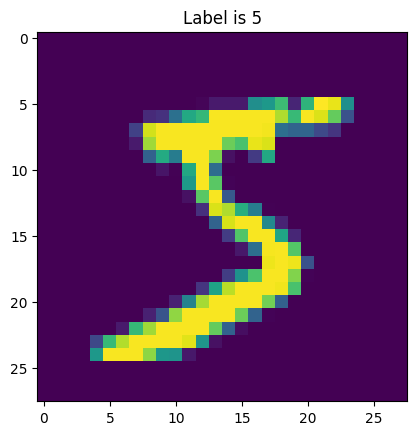

In [ ]:
Image=Xtr[0,:,:]
Label=Ltr[0]

plt.title('Label is {Label}'.format(Label=Label))
plt.imshow(Image)

plt.show()
plt.close()


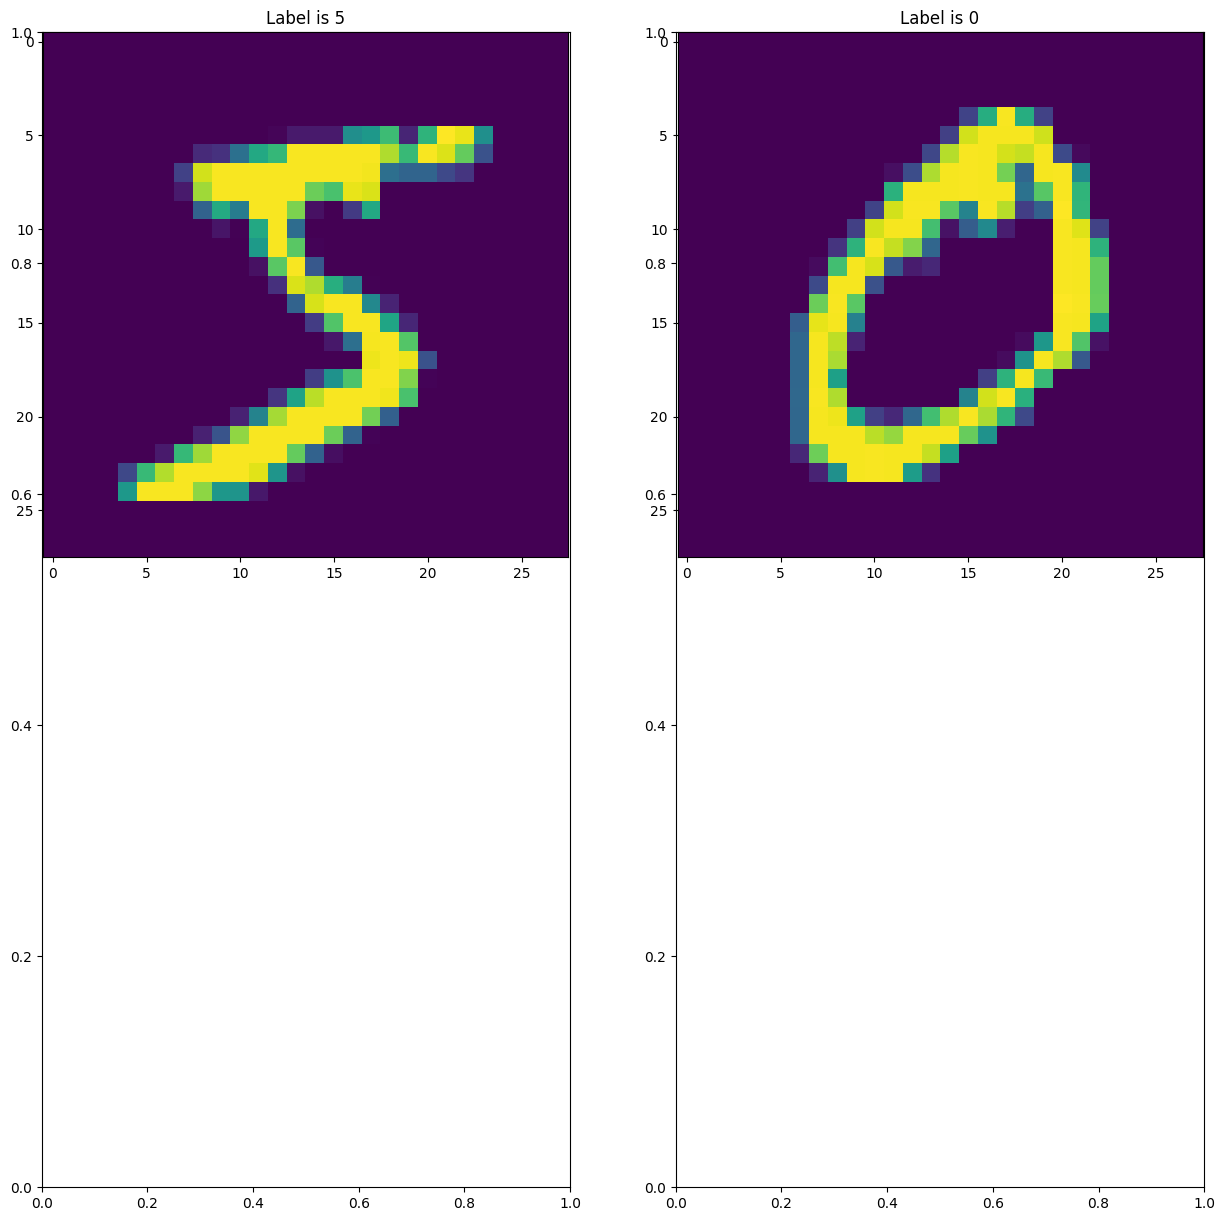

In [ ]:
fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(15,15))
ax0=plt.subplot(2,2,1)
ax1=plt.subplot(2,2,2)

Image=Xtr[0,:,:]
Label=Ltr[0]
Image1=Xtr[1,:,:]
Label1=Ltr[1]


ax0.set_title('Label is {Label}'.format(Label=Label))
ax0.imshow(Image)
ax1.set_title('Label is {Label}'.format(Label=Label1))
ax1.imshow(Image1)


plt.show()
plt.close()


In [ ]:
28*28

784

In [ ]:
#Traing phase
num_sample=500
Tr_set=Xtr[:num_sample,:,:]
Ltr_set=Ltr[:num_sample]

Tr_set=Tr_set.reshape(num_sample,Tr_set.shape[1]*Tr_set.shape[2])

#Tr_set=Tr_set.reshape(num_sample,Tr_set.shape[1]*Tr_set.shape[2]).astype()
Tr_set.shape

(500, 784)

In [ ]:
def predict(X):
    num_test=X.shape[0]
    Lpred=np.zeros(num_test, dtype=Ltr_set.dtype)

    for i in range(num_test):
        distances=np.sum(np.abs(Tr_set-X[i,:]),axis=1)

        min_index= np.argmin(distances)
        Lpred[i]=Ltr_set[min_index]
    return Lpred

In [ ]:
Test_images=X_test.reshape(X_test.shape[0],X_test.shape[1]* X_test.shape[2])
Labels_predicted=predict(Test_images)

print("Accuracy:", np.mean(Labels_predicted==L_test))


Accuracy: 0.2649


### Test code with a 1-NN classifier. What is the accuracy of the method?

We can see the accuracy is about 27%

### Implement L2 Euclidan distance
Implement NearestNeighbor example so that it uses L2 norm for classification

In [ ]:
def predictL2(X):
    num_test=X.shape[0]
    Lpred=np.zeros(num_test, dtype=Ltr_set.dtype)

    # We are going to change the code to L2
    for i in range(num_test):
        distances = np.sum((Tr_set - X[i, :]) ** 2, axis=1) ** 0.5 # here

        min_index= np.argmin(distances)
        Lpred[i]=Ltr_set[min_index]
    return Lpred

In [ ]:
# Running with L2 euclidian distance
Test_images=X_test.reshape(X_test.shape[0],X_test.shape[1]* X_test.shape[2])
Labels_predicted=predictL2(Test_images)

print("Accuracy:", np.mean(Labels_predicted==L_test))

Accuracy: 0.19


Accuracy is even lower and like 19%.


### Normalization, and remove any extreme values and see whats happening

In [ ]:
def predict_L2_normalzed(X):
    num_test = X.shape[0]
    Lpred = np.zeros(num_test)

    # Here we normalize in range 0 - 1
    Tr_set_normalized = Tr_set / 255.0
    X_normalized = X / 255.0

    for i in range(num_test):
        distances = np.sum((Tr_set_normalized - X_normalized[i, :]) ** 2, axis=1) ** 0.5
        min_index = np.argmin(distances)
        Lpred[i] = Ltr_set[min_index]

    return Lpred


In [ ]:
# Running with normalized dataset
Test_images=X_test.reshape(X_test.shape[0],X_test.shape[1]* X_test.shape[2])
Labels_predicted=predict_L2_normalzed(Test_images)

print("Accuracy:", np.mean(Labels_predicted==L_test))


Accuracy: 0.8294


Got 83% accuracry this time, and it probably because high dimential data can blow up if we have high dimentional data if not normalized before hand and certain data types unable to time to handle this. This shows we sometimes need to preprocess data and also consider data types in the code.

### Implement a k-NN klassifier.

In [ ]:
def crossvalidate(X, L, k_values, num_folds=3):

    # Now we split data into folds for validation
    folds = cross_validation_split(X, L, num_folds)
    accuracies = {k: [] for k in k_values}

    for fold_idx in range(num_folds):
        # and do separation this fold into training and validation set
        validation_indices = folds[fold_idx]
        train_indices = np.concatenate([folds[i] for i in range(num_folds) if i != fold_idx])

        X_train, L_train = X[train_indices], L[train_indices]
        X_val, L_val = X[validation_indices], L[validation_indices]

        for k in k_values:
            # Predict on the validation set and store accuracy
            predictions = predict_kNN(X_val, X_train, L_train, k, norm=normL2)
            accuracies[k].append(np.mean(predictions == L_val))

    # Find the best k based on avg accuracy
    mean_accuracies = {k: np.mean(acc) for k, acc in accuracies.items()}
    best_k = max(mean_accuracies, key=mean_accuracies.get)

    return best_k, mean_accuracies


In [ ]:

def normL2(X1, X2):
    # Euclidian distrance
    return np.sqrt(np.sum((X1 - X2) ** 2, axis=1))

def predict_kNN(X, Tr_set, Ltr_set, k, norm=normL2):

    # Normalize training and test data
    Tr_set_normalized = Tr_set / 255.0
    X_normalized = X / 255.0

    num_test = X.shape[0]
    Lpred = np.zeros(num_test, dtype=Ltr_set.dtype)

    for i in range(num_test):
        distances = norm(Tr_set_normalized, X_normalized[i, :])
        min_index = np.argsort(distances)[:k]

        # Get the most common label for k neighbours
        Lpred[i] = np.argmax(np.bincount(Ltr_set[min_index])) # checking the bins

    return Lpred


Testing different k- values from 1 to 4.

In [ ]:
for k in range(1, 5):
    predictions = predict_kNN(Test_images, Tr_set, Ltr_set, k)
    accuracy = np.mean(predictions == L_test)
    print(f"Accuracy  k = {k}: {accuracy}")

Accuracy  k = 1: 0.8294
Accuracy  k = 2: 0.8037
Accuracy  k = 3: 0.8061
Accuracy  k = 4: 0.805


We can see that the accuracy is dropping, indicating that that k=1 is optimal.

## Hyperparameters and cross-validation

### 3-fold cross validation, together with L2 norm as distance calulation

First, we need to split up the the training data, into 3 folds.

In [ ]:
def cross_validation_split(data, labels, num_folds=3):
    fold_size = len(data) // num_folds  # We dont want float here
    indices = np.arange(len(data))
    np.random.shuffle(indices)  # Shuffle

    folds = [indices[i * fold_size:(i + 1) * fold_size] for i in range(num_folds)]
    return folds


Setting up the test

In [ ]:
k_values = [1, 3, 5, 7]  # Testing values
best_k, k_accuracies = crossvalidate(Tr_set, Ltr_set, k_values)

print(f"Best k value is: {best_k}")
print("\n Cross-validation accuracies:")
for k, acc in k_accuracies.items():
    print(f"k={k}: {acc}")


Best k value is: 1

 Cross-validation accuracies:
k=1: 0.8493975903614458
k=3: 0.8393574297188754
k=5: 0.8293172690763052
k=7: 0.8232931726907631


In [ ]:
# Evaluate for the best k on our test set
predictions = predict_kNN(Test_images, Tr_set, Ltr_set, best_k, norm=normL2)
final_accuracy = np.mean(predictions == L_test)
print(f"Final accuracy on the test set with k={best_k}: {final_accuracy:.4f}")


Final accuracy on the test set with k=1: 0.8294


---
### Implement SVM

Import  libraries


In [1]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

Load the Iris dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data     # Features
y = iris.target   # Labels
feature_names = iris.feature_names

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

kernels = ['linear', 'poly', 'rbf']
results = []

---

Make a confusion matrices for 1-vs-1 and 1-vs-rest

In [ ]:
# Split into train-test sets (80:20)
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create SVM models as in the blog
# OvR: One-vs-Rest
linear_OvR = SVC(kernel='linear', decision_function_shape="ovr").fit(X_train, y_train)
poly_OvR = SVC(kernel='poly', decision_function_shape="ovr").fit(X_train, y_train)
rbf_OvR = SVC(kernel='rbf', decision_function_shape="ovr").fit(X_train, y_train)

# OvO: One-vs-One
linear_OvO = SVC(kernel='linear', decision_function_shape="ovo").fit(X_train, y_train)
poly_OvO = SVC(kernel='poly', decision_function_shape="ovo").fit(X_train, y_train)
rbf_OvO = SVC(kernel='rbf', decision_function_shape="ovo").fit(X_train, y_train)

# confusion matrices, accuracy, and F1 scores
def evaluate_model(model, kernel, approach):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- Evaluating {kernel.upper()} Kernel with {approach.upper()} Approach ---")
    print(f"Confusion Matrix ({approach.upper()}):\n{cm}")
    print(f"Accuracy ({approach.upper()}): {acc:.2f}")
    print(f"F1 Score ({approach.upper()}): {f1:.2f}\n")

# Evaluate each model
print("\n Construct confusion matrices and Evaluate SVM Models")
evaluate_model(linear_OvR, 'linear', 'ovr')
evaluate_model(poly_OvR, 'poly', 'ovr')
evaluate_model(rbf_OvR, 'rbf', 'ovr')

evaluate_model(linear_OvO, 'linear', 'ovo')
evaluate_model(poly_OvO, 'poly', 'ovo')
evaluate_model(rbf_OvO, 'rbf', 'ovo')


Task 1: Construct Confusion Matrices and Evaluate SVM Models
--- Evaluating LINEAR Kernel with OVR Approach ---
Confusion Matrix (OVR):
[[ 8  0  0]
 [ 0  9  0]
 [ 0  0 13]]
Accuracy (OVR): 1.00
F1 Score (OVR): 1.00

--- Evaluating POLY Kernel with OVR Approach ---
Confusion Matrix (OVR):
[[ 8  0  0]
 [ 0  9  0]
 [ 0  1 12]]
Accuracy (OVR): 0.97
F1 Score (OVR): 0.97

--- Evaluating RBF Kernel with OVR Approach ---
Confusion Matrix (OVR):
[[ 8  0  0]
 [ 0  9  0]
 [ 0  1 12]]
Accuracy (OVR): 0.97
F1 Score (OVR): 0.97

--- Evaluating LINEAR Kernel with OVO Approach ---
Confusion Matrix (OVO):
[[ 8  0  0]
 [ 0  9  0]
 [ 0  0 13]]
Accuracy (OVO): 1.00
F1 Score (OVO): 1.00

--- Evaluating POLY Kernel with OVO Approach ---
Confusion Matrix (OVO):
[[ 8  0  0]
 [ 0  9  0]
 [ 0  1 12]]
Accuracy (OVO): 0.97
F1 Score (OVO): 0.97

--- Evaluating RBF Kernel with OVO Approach ---
Confusion Matrix (OVO):
[[ 8  0  0]
 [ 0  9  0]
 [ 0  1 12]]
Accuracy (OVO): 0.97
F1 Score (OVO): 0.97



---
Finding best kernel based on accuracy and F1 score

In [ ]:
# Extract Support Vectors
def extract_support_vectors(kernel, approach, X_train, y_train):

    # Train the model
    clf = SVC(kernel=kernel, decision_function_shape=approach)
    clf.fit(X_train, y_train)

    # Extract the support vectors
    support_vectors = clf.support_vectors_

    print(f"\n--- Support Vectors for {kernel.upper()} Kernel ({approach.upper()}) ---")
    print(support_vectors)

kernels = ['linear', 'poly', 'rbf']
approaches = ['ovr', 'ovo']

# Extract Support Vectors
print("\nExtract Support Vectors")
for kernel in kernels:
    for approach in approaches:
        extract_support_vectors(kernel, approach, X_train, y_train)


Task 3: Extract Support Vectors

--- Task 3: Support Vectors for LINEAR Kernel (OVR) ---
[[4.5 2.3 1.3 0.3]
 [4.8 3.4 1.9 0.2]
 [5.1 3.8 1.9 0.4]
 [6.8 2.8 4.8 1.4]
 [6.1 2.9 4.7 1.4]
 [6.7 3.  5.  1.7]
 [6.3 2.5 4.9 1.5]
 [6.2 2.2 4.5 1.5]
 [5.1 2.5 3.  1.1]
 [5.4 3.  4.5 1.5]
 [6.  2.7 5.1 1.6]
 [6.9 3.1 4.9 1.5]
 [6.3 3.3 4.7 1.6]
 [5.9 3.2 4.8 1.8]
 [6.5 3.  5.2 2. ]
 [6.  3.  4.8 1.8]
 [6.3 2.8 5.1 1.5]
 [6.3 2.5 5.  1.9]
 [6.1 3.  4.9 1.8]
 [6.1 2.6 5.6 1.4]
 [6.3 2.7 4.9 1.8]
 [6.  2.2 5.  1.5]
 [6.2 2.8 4.8 1.8]
 [6.5 3.2 5.1 2. ]
 [7.2 3.  5.8 1.6]
 [5.6 2.8 4.9 2. ]]

--- Task 3: Support Vectors for LINEAR Kernel (OVO) ---
[[4.5 2.3 1.3 0.3]
 [4.8 3.4 1.9 0.2]
 [5.1 3.8 1.9 0.4]
 [6.8 2.8 4.8 1.4]
 [6.1 2.9 4.7 1.4]
 [6.7 3.  5.  1.7]
 [6.3 2.5 4.9 1.5]
 [6.2 2.2 4.5 1.5]
 [5.1 2.5 3.  1.1]
 [5.4 3.  4.5 1.5]
 [6.  2.7 5.1 1.6]
 [6.9 3.1 4.9 1.5]
 [6.3 3.3 4.7 1.6]
 [5.9 3.2 4.8 1.8]
 [6.5 3.  5.2 2. ]
 [6.  3.  4.8 1.8]
 [6.3 2.8 5.1 1.5]
 [6.3 2.5 5.  1.9]
 [6.1 3.  4.9 1.

Plot the decision bounderies and support vectors

Boundary for features 2 vs 3


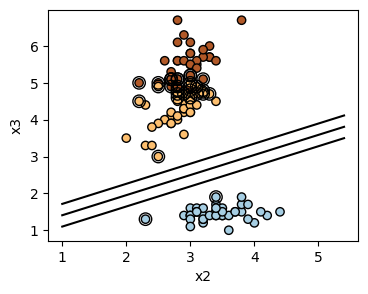

Boundary for features 3 vs 4


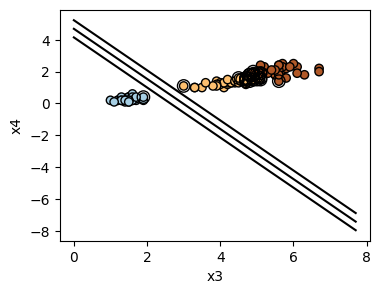

In [10]:
import numpy as np
import matplotlib.pyplot as plt


# Plotting support vectors
def plot_decision_boundary(kernel, X, y, feature1, feature2):
    # Train SVM on selected features
    clf = SVC(kernel=kernel, C=1)
    X_plot = X[:, [feature1, feature2]]
    clf.fit(X_plot, y)

    # separating hyperplane
    w = clf.coef_[0]
    a = -w[0] / w[1]
    xx = np.linspace(X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1, 500)
    yy = a * xx - (clf.intercept_[0]) / w[1]

    # Compute margins
    margin = 1 / np.sqrt(np.sum(clf.coef_ ** 2))
    yy_down = yy - np.sqrt(1 + a ** 2) * margin
    yy_up = yy + np.sqrt(1 + a ** 2) * margin

    # decision boundary and margins
    plt.figure(figsize=(4, 3))
    plt.plot(xx, yy, "k-")  # decision boundary
    plt.plot(xx, yy_down, "k-")  # Margin below
    plt.plot(xx, yy_up, "k-")  # Margin above

    # Scatter data points
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, cmap=plt.cm.Paired, edgecolors="k", zorder=10)
    plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=80,
                facecolors="none", edgecolors="k", zorder=10)

    # Labels
    plt.xlabel(f"x{feature1 + 1}")
    plt.ylabel(f"x{feature2 + 1}")
    plt.show()

# 2 vs 3
print("Boundary for features 2 vs 3")
plot_decision_boundary('linear', X_train, y_train, feature1=1, feature2=2)

#  3 vs 4
print("Boundary for features 3 vs 4")
plot_decision_boundary('linear', X_train, y_train, feature1=2, feature2=3)
